# LG Investor Forum 2024 워드클라우드 분석

이 노트북은 LG_Investor_Forum_2024.pdf 파일의 내용을 분석하여 워드클라우드를 생성합니다.
명사와 외래어 중심으로 토큰을 추출하여 시각화합니다.

## 1. 필요한 라이브러리 설치 및 임포트

In [13]:
# 필요한 라이브러리 설치
!pip install PyPDF2 wordcloud matplotlib konlpy pandas numpy seaborn
!pip install python-pptx
!pip install pdfplumber

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [14]:
# 라이브러리 임포트
import PyPDF2
import pdfplumber
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows의 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False

# 형태소 분석기 임포트
try:
    from konlpy.tag import Okt, Kkma, Hannanum
    konlpy_available = True
    print("KoNLPy 라이브러리가 성공적으로 로드되었습니다.")
except ImportError:
    konlpy_available = False
    print("KoNLPy 라이브러리를 설치해주세요: pip install konlpy")
    print("또는 Java가 설치되어 있는지 확인해주세요.")

KoNLPy 라이브러리가 성공적으로 로드되었습니다.


## 2. PDF 파일 텍스트 추출

In [15]:
# PDF 파일 경로
pdf_path = r"c:\Users\lgdx\LG_DX_School\02_DX_Methodology\IR_Report\LG_Investor_Forum_2024.pdf"

def extract_text_from_pdf(pdf_path):
    """
    PDF 파일에서 텍스트를 추출하는 함수
    여러 방법을 시도하여 최적의 결과를 얻습니다.
    """
    text = ""
    
    # 방법 1: pdfplumber 사용 (더 정확한 텍스트 추출)
    try:
        print("pdfplumber를 사용하여 텍스트를 추출 중...")
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
                if i % 10 == 0:
                    print(f"페이지 {i+1}/{len(pdf.pages)} 처리 중...")
        print(f"pdfplumber로 총 {len(text)} 문자 추출 완료")
        
    except Exception as e:
        print(f"pdfplumber 오류: {e}")
        
        # 방법 2: PyPDF2 사용 (fallback)
        try:
            print("PyPDF2를 사용하여 텍스트를 추출 중...")
            with open(pdf_path, 'rb') as file:
                pdf_reader = PyPDF2.PdfReader(file)
                for i, page in enumerate(pdf_reader.pages):
                    page_text = page.extract_text()
                    if page_text:
                        text += page_text + "\n"
                    if i % 10 == 0:
                        print(f"페이지 {i+1}/{len(pdf_reader.pages)} 처리 중...")
            print(f"PyPDF2로 총 {len(text)} 문자 추출 완료")
            
        except Exception as e2:
            print(f"PyPDF2 오류: {e2}")
            return None
    
    return text

# 텍스트 추출 실행
raw_text = extract_text_from_pdf(pdf_path)

if raw_text:
    print(f"\n총 추출된 텍스트 길이: {len(raw_text):,} 문자")
    print("\n추출된 텍스트 샘플 (첫 500자):")
    print("=" * 50)
    print(raw_text[:500])
    print("=" * 50)
else:
    print("텍스트 추출에 실패했습니다.")

pdfplumber를 사용하여 텍스트를 추출 중...
페이지 1/109 처리 중...


Cannot set gray non-stroke color because /'P163' is an invalid float value
Cannot set gray non-stroke color because /'P169' is an invalid float value
Cannot set gray non-stroke color because /'P174' is an invalid float value
Cannot set gray non-stroke color because /'P179' is an invalid float value
Cannot set gray non-stroke color because /'P184' is an invalid float value
Cannot set gray non-stroke color because /'P189' is an invalid float value
Cannot set gray non-stroke color because /'P204' is an invalid float value
Cannot set gray non-stroke color because /'P169' is an invalid float value
Cannot set gray non-stroke color because /'P174' is an invalid float value
Cannot set gray non-stroke color because /'P179' is an invalid float value
Cannot set gray non-stroke color because /'P184' is an invalid float value
Cannot set gray non-stroke color because /'P189' is an invalid float value
Cannot set gray non-stroke color because /'P204' is an invalid float value
Cannot set gray non-strok

페이지 11/109 처리 중...


Cannot set gray non-stroke color because /'P481' is an invalid float value
Cannot set gray non-stroke color because /'P526' is an invalid float value
Cannot set gray non-stroke color because /'P559' is an invalid float value
Cannot set gray non-stroke color because /'P604' is an invalid float value
Cannot set gray non-stroke color because /'P526' is an invalid float value
Cannot set gray non-stroke color because /'P559' is an invalid float value
Cannot set gray non-stroke color because /'P604' is an invalid float value
Cannot set gray non-stroke color because /'P631' is an invalid float value
Cannot set gray non-stroke color because /'P670' is an invalid float value
Cannot set gray non-stroke color because /'P711' is an invalid float value
Cannot set gray non-stroke color because /'P736' is an invalid float value
Cannot set gray non-stroke color because /'P631' is an invalid float value
Cannot set gray non-stroke color because /'P670' is an invalid float value
Cannot set gray non-strok

페이지 21/109 처리 중...


...

페이지 91/109 처리 중...


Cannot set gray non-stroke color because /'P6809' is an invalid float value
Cannot set gray non-stroke color because /'P6815' is an invalid float value
Cannot set gray non-stroke color because /'P6821' is an invalid float value
Cannot set gray non-stroke color because /'P6843' is an invalid float value
Cannot set gray non-stroke color because /'P6872' is an invalid float value
Cannot set gray non-stroke color because /'P6901' is an invalid float value
Cannot set gray non-stroke color because /'P6930' is an invalid float value
Cannot set gray non-stroke color because /'P6815' is an invalid float value
Cannot set gray non-stroke color because /'P6821' is an invalid float value
Cannot set gray non-stroke color because /'P6843' is an invalid float value
Cannot set gray non-stroke color because /'P6872' is an invalid float value
Cannot set gray non-stroke color because /'P6901' is an invalid float value
Cannot set gray non-stroke color because /'P6930' is an invalid float value
Cannot set g

페이지 101/109 처리 중...


Cannot set gray non-stroke color because /'P7239' is an invalid float value
Cannot set gray non-stroke color because /'P7262' is an invalid float value
Cannot set gray non-stroke color because /'P7287' is an invalid float value
Cannot set gray non-stroke color because /'P7262' is an invalid float value
Cannot set gray non-stroke color because /'P7287' is an invalid float value
Cannot set gray non-stroke color because /'P7317' is an invalid float value
Cannot set gray non-stroke color because /'P7344' is an invalid float value
Cannot set gray non-stroke color because /'P7365' is an invalid float value
Cannot set gray non-stroke color because /'P7317' is an invalid float value
Cannot set gray non-stroke color because /'P7344' is an invalid float value
Cannot set gray non-stroke color because /'P7365' is an invalid float value
Cannot set gray non-stroke color because /'P7403' is an invalid float value
Cannot set gray non-stroke color because /'P7403' is an invalid float value
Cannot set g

pdfplumber로 총 15687 문자 추출 완료

총 추출된 텍스트 길이: 15,687 문자

추출된 텍스트 샘플 (첫 500자):
LG전자 Investor Forum
LG전자의 Unicorn 및 Seed 사업
조 주 완
LG전자 CEO
1 2 3
미래비전 2030 유니콘 사업 및 중장기 사업 포트폴리오
추진 경과 Seed 사업 전환목표
1
미래비전 2030
추진 경과
LG전자 Investor Forum
SSmmaarrtt LLiiffee SSoolluuttiioonn CCoommppaannyy
고객의 삶이 있는 모든 공간에서, 고객의 경험을 연결하고 확장
LG전자 Investor Forum
SSmmaarrtt LLiiffee SSoolluuttiioonn CCoommppaannyy
고객의 삶이 있는 모든 공간에서, 고객의 경험을 연결하고 확장
홈 커머셜 모빌리티 가상공간
사업영역
솔루션 솔루션 솔루션 솔루션
혁신방식 기존 사업 잠재력 극대화 사업 구조 혁신
고객경험 Connectivity Caring Customization Servitization Sustainability
미래 변곡점 Servitizatio


## 3. 텍스트 전처리

In [16]:
def preprocess_text(text):
    """
    텍스트 전처리 함수
    - 불필요한 문자 제거
    - 공백 정리
    - 특수문자 처리
    """
    if not text:
        return ""
    
    # 연속된 공백, 탭, 줄바꿈 정리
    text = re.sub(r'\s+', ' ', text)
    
    # 특수문자 중 의미있는 것들만 유지 (%, $, 등)
    # 괄호, 쉼표, 마침표는 유지
    text = re.sub(r'[^가-힣a-zA-Z0-9\s%$.,()\-+]', ' ', text)
    
    # 숫자만 있는 단독 토큰 제거 (페이지 번호 등)
    text = re.sub(r'\b\d+\b', '', text)
    
    # 연속된 공백 재정리
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# 텍스트 전처리 실행
if raw_text:
    cleaned_text = preprocess_text(raw_text)
    print(f"전처리 후 텍스트 길이: {len(cleaned_text):,} 문자")
    print("\n전처리된 텍스트 샘플 (첫 500자):")
    print("=" * 50)
    print(cleaned_text[:500])
    print("=" * 50)
else:
    print("전처리할 텍스트가 없습니다.")

전처리 후 텍스트 길이: 14,502 문자

전처리된 텍스트 샘플 (첫 500자):
LG전자 Investor Forum LG전자의 Unicorn 및 Seed 사업 조 주 완 LG전자 CEO 미래비전 유니콘 사업 및 중장기 사업 포트폴리오 추진 경과 Seed 사업 전환목표 미래비전 추진 경과 LG전자 Investor Forum SSmmaarrtt LLiiffee SSoolluuttiioonn CCoommppaannyy 고객의 삶이 있는 모든 공간에서, 고객의 경험을 연결하고 확장 LG전자 Investor Forum SSmmaarrtt LLiiffee SSoolluuttiioonn CCoommppaannyy 고객의 삶이 있는 모든 공간에서, 고객의 경험을 연결하고 확장 홈 커머셜 모빌리티 가상공간 사업영역 솔루션 솔루션 솔루션 솔루션 혁신방식 기존 사업 잠재력 극대화 사업 구조 혁신 고객경험 Connectivity Caring Customization Servitization Sustainability 미래 변곡점 Servitization Digitalization E


## 4. 명사 및 외래어 추출

In [17]:
def extract_nouns_and_foreign_words(text):
    """
    텍스트에서 명사와 외래어를 추출하는 함수
    """
    print("Java가 설치되어 있지 않아 패턴 매칭을 사용합니다.")
    return extract_words_by_pattern(text)

def extract_words_by_pattern(text):
    """
    패턴 매칭을 통한 단어 추출 (KoNLPy 없을 때 사용)
    """
    # 한글 단어 (2자 이상) - 중복 허용
    korean_words = re.findall(r'[가-힣]{2,}', text)
    
    # 영어 단어 (2자 이상) - 중복 허용
    english_words = re.findall(r'[A-Za-z]{2,}', text)
    
    # 숫자+단위 (예: 10%, 5조원) - 중복 허용
    number_units = re.findall(r'\d+[%원조억만천달러]', text)
    
    all_words = korean_words + english_words + number_units
    
    # 불용어 필터링 (중복은 제거하지 않음)
    stopwords = ['것', '수', '등', '및', '또는', '하는', '있는', '되는', '같은', '위해', '통해', '대한', '관련', 
                '그', '이', '그것', '저것', '여기', '거기', '저기', '때문', '따라', 'of', 'the', 'and', 'to', 'in', 'for',
                'LG', '전자', '사업', 'Investor', 'Forum', '사업의', 
                ]
    
    filtered_words = []
    for word in all_words:
        if word not in stopwords and len(word) >= 2:
            filtered_words.append(word)
    
    return filtered_words

# 단어 추출 실행
if 'cleaned_text' in locals() and cleaned_text:
    extracted_words = extract_nouns_and_foreign_words(cleaned_text)
    
    # 단어 빈도 계산
    word_freq = Counter(extracted_words)
    
    print(f"\n총 {len(word_freq)} 개의 고유 단어 추출")
    print(f"총 {len(extracted_words)} 개의 단어 토큰 추출")
    print("\n상위 20개 단어:")
    print("=" * 40)
    for word, freq in word_freq.most_common(20):
        print(f"{word}: {freq}")
    print("=" * 40)
else:
    print("추출할 텍스트가 없습니다.")

Java가 설치되어 있지 않아 패턴 매칭을 사용합니다.

총 924 개의 고유 단어 추출
총 2443 개의 단어 토큰 추출

상위 20개 단어:
서비스: 62
플랫폼: 45
성장: 42
webOS: 39
확대: 30
글로벌: 29
고객: 28
파트너십: 27
강화: 27
매출: 26
기반: 24
TV: 22
년간: 19
솔루션: 17
구독: 17
쌓아온: 17
역량과: 17
기존: 16
냉각: 16
극대화: 15


## 5. 워드클라우드 생성

전체 워드클라우드 생성 중...


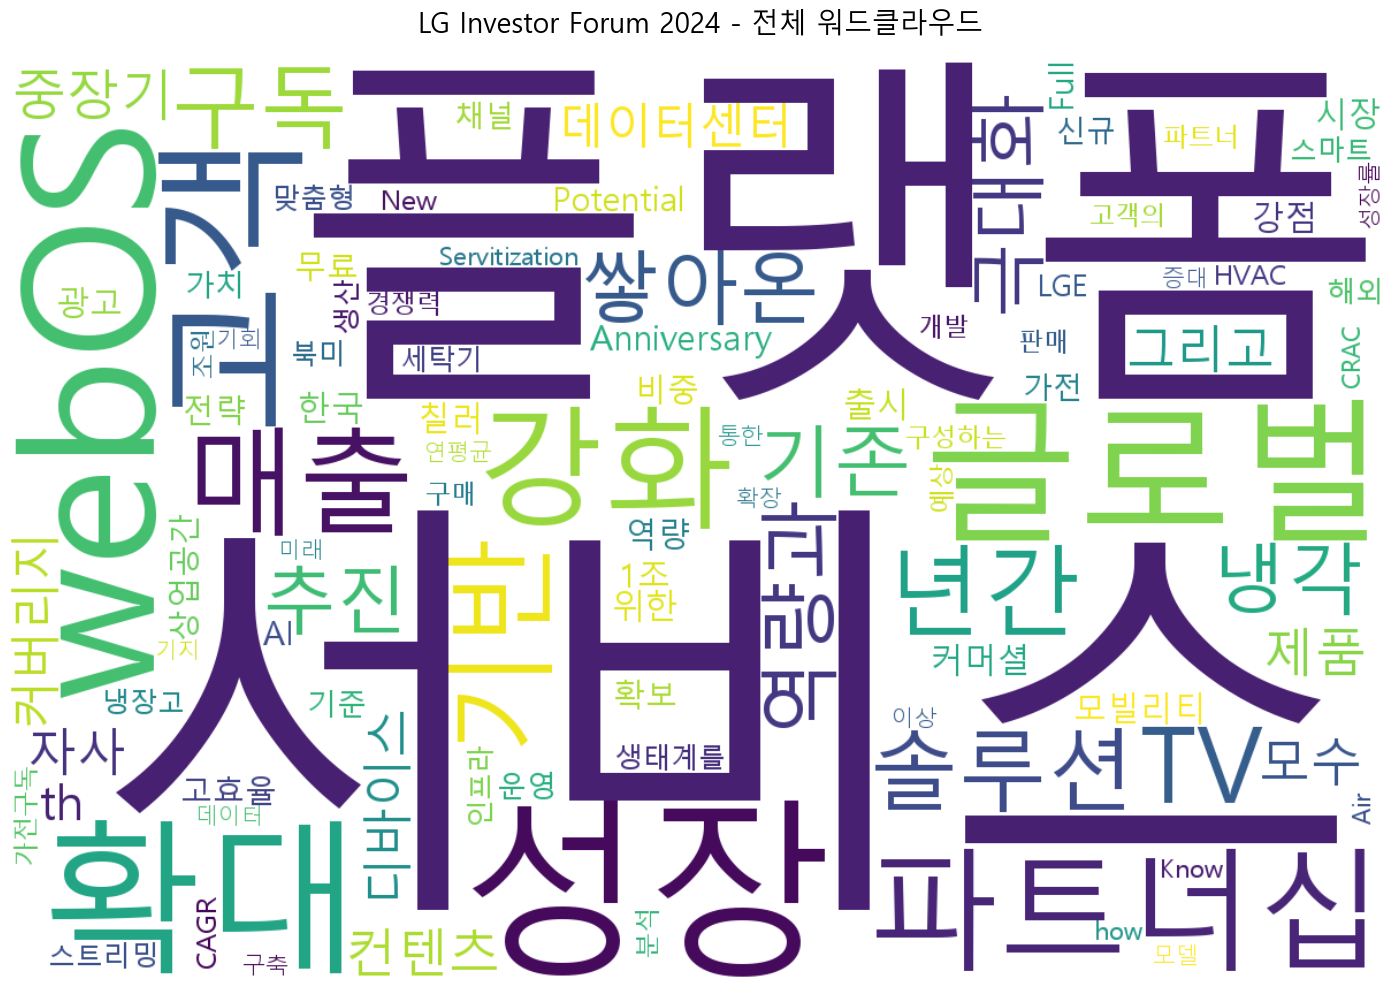


상위 50개 단어로 워드클라우드 생성 중...


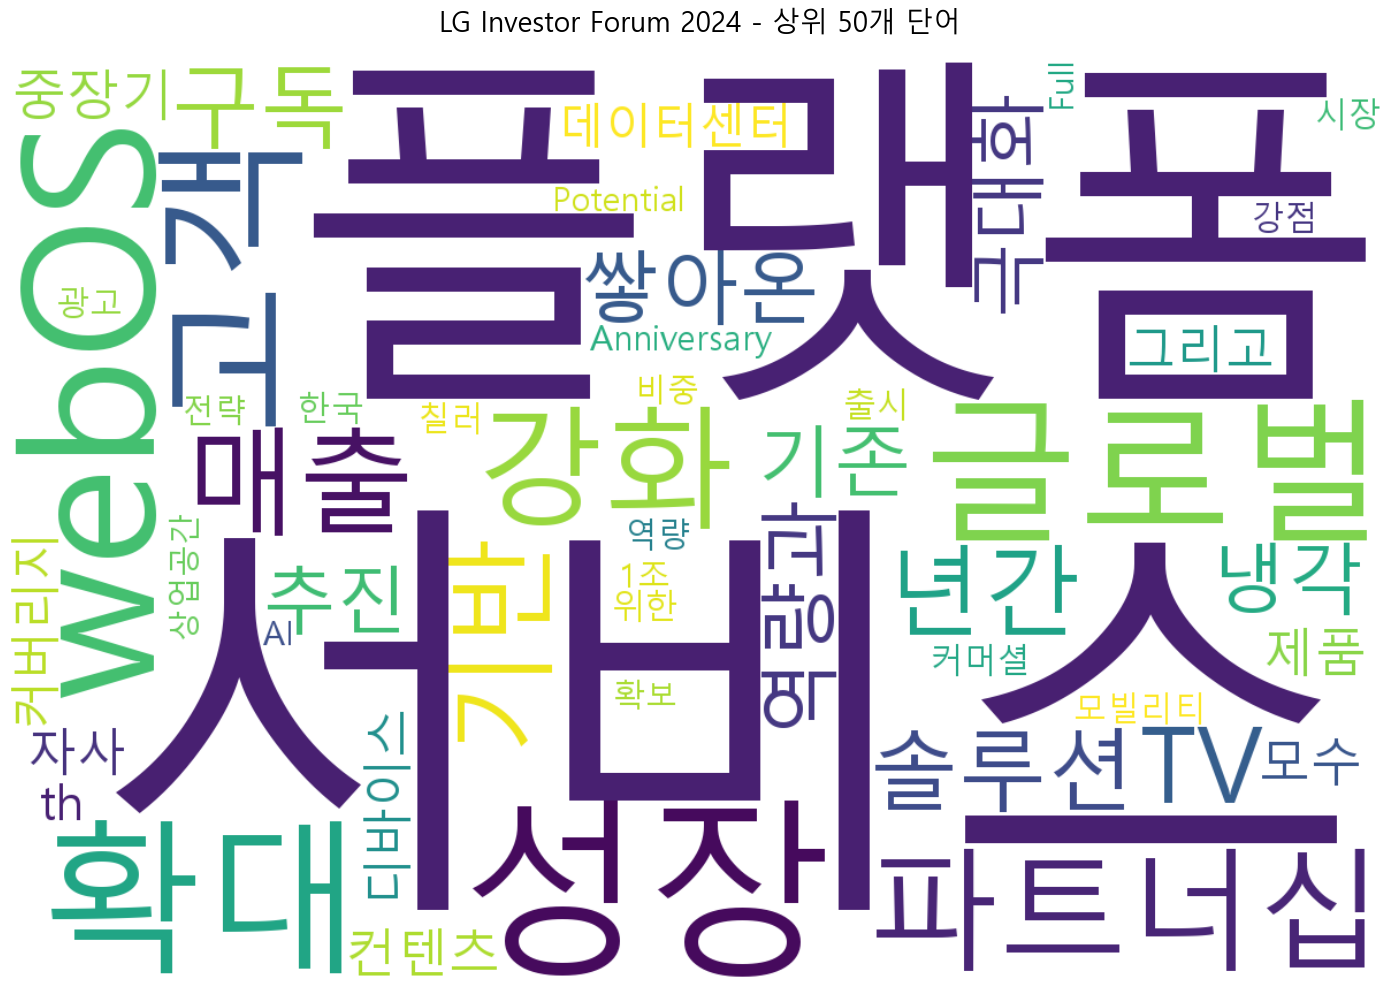

In [23]:
def create_wordcloud(word_freq, title="Word Cloud", min_font_size=10, max_words=100):
    """
    워드클라우드 생성 함수
    """
    if not word_freq:
        print("워드클라우드를 생성할 단어가 없습니다.")
        return None
    
    # 워드클라우드 설정
    wordcloud = WordCloud(
        font_path='C:/Windows/Fonts/malgun.ttf',  # 맑은 고딕 폰트
        width=1200,
        height=800,
        background_color='white',
        max_words=max_words,
        min_font_size=min_font_size,
        colormap='viridis',
        relative_scaling=0.5,
        random_state=42
    ).generate_from_frequencies(word_freq)
    
    # 시각화
    plt.figure(figsize=(15, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20, pad=20)
    plt.tight_layout()
    
    return wordcloud

# 전체 워드클라우드 생성
if 'word_freq' in locals() and word_freq:
    print("전체 워드클라우드 생성 중...")
    wc_all = create_wordcloud(word_freq, "LG Investor Forum 2024 - 전체 워드클라우드", max_words=100)
    plt.show()
    
    # 상위 빈도 단어만으로 워드클라우드 생성
    print("\n상위 50개 단어로 워드클라우드 생성 중...")
    top_50_freq = dict(word_freq.most_common(50))
    wc_top = create_wordcloud(top_50_freq, "LG Investor Forum 2024 - 상위 50개 단어", max_words=50)
    plt.show()
else:
    print("워드클라우드를 생성할 데이터가 없습니다.")

## 6. 빈도 분석 차트

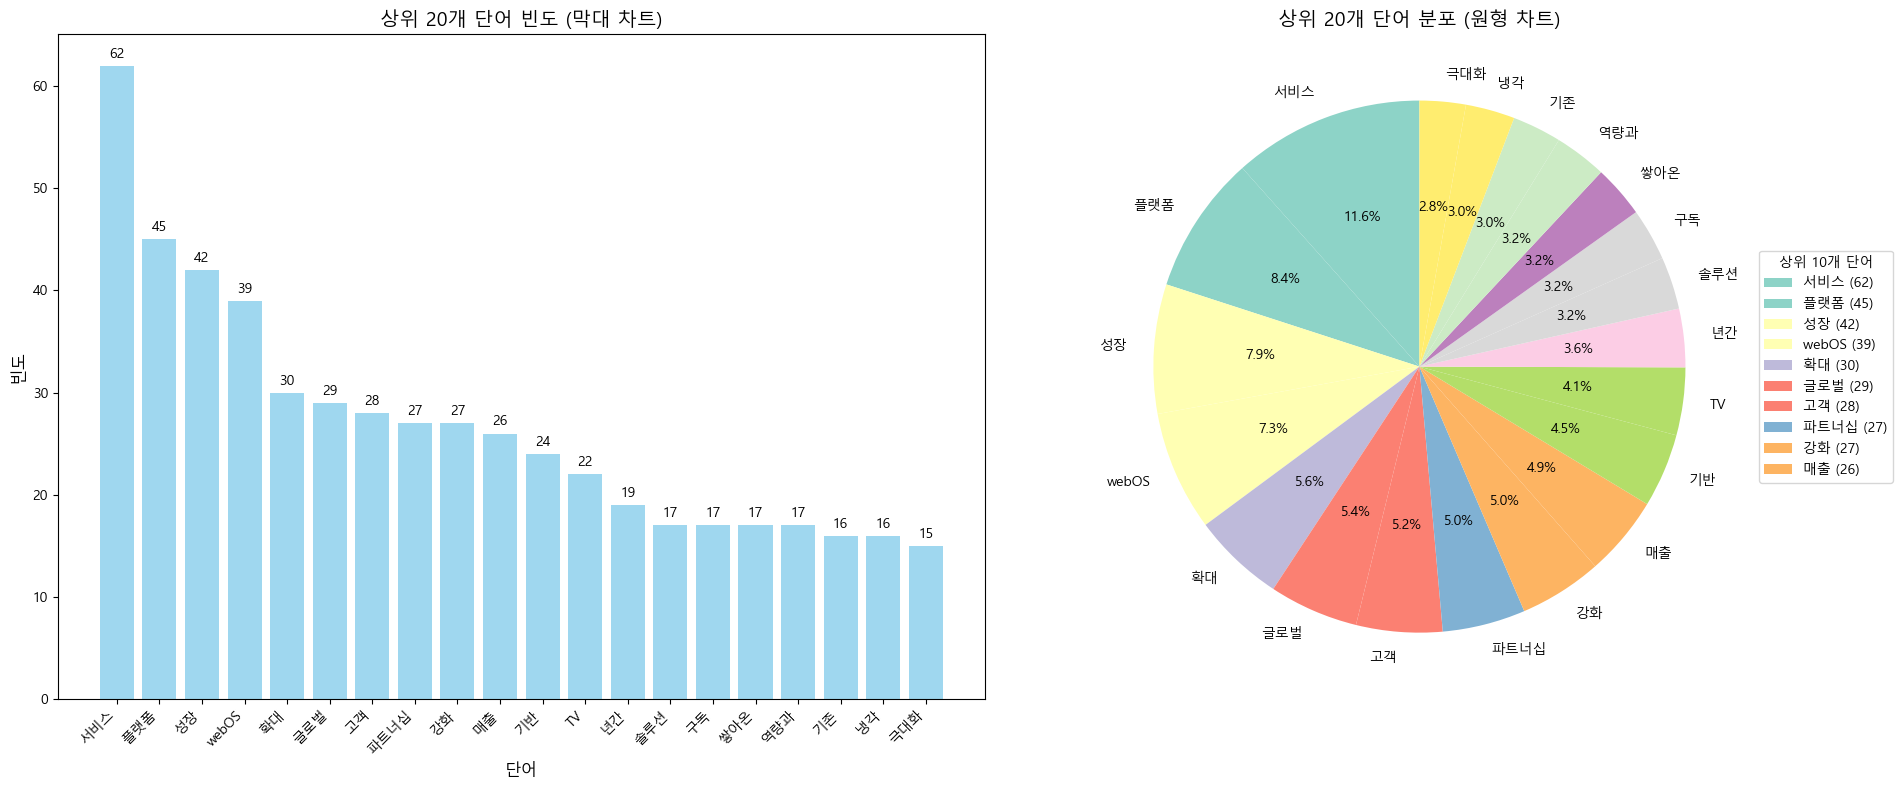


상위 20개 단어 빈도표:
   단어  빈도
  서비스  62
  플랫폼  45
   성장  42
webOS  39
   확대  30
  글로벌  29
   고객  28
 파트너십  27
   강화  27
   매출  26
   기반  24
   TV  22
   년간  19
  솔루션  17
   구독  17
  쌓아온  17
  역량과  17
   기존  16
   냉각  16
  극대화  15


In [24]:
def create_frequency_charts(word_freq, top_n=20):
    """
    단어 빈도 분석 차트 생성
    """
    if not word_freq:
        print("분석할 데이터가 없습니다.")
        return
    
    # 상위 N개 단어 추출
    top_words = word_freq.most_common(top_n)
    words, frequencies = zip(*top_words)
    
    # 데이터프레임 생성
    df = pd.DataFrame({
        '단어': words,
        '빈도': frequencies
    })
    
    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # 막대 차트
    bars = ax1.bar(range(len(words)), frequencies, color='skyblue', alpha=0.8)
    ax1.set_xlabel('단어', fontsize=12)
    ax1.set_ylabel('빈도', fontsize=12)
    ax1.set_title(f'상위 {top_n}개 단어 빈도 (막대 차트)', fontsize=14)
    ax1.set_xticks(range(len(words)))
    ax1.set_xticklabels(words, rotation=45, ha='right')
    
    # 막대 위에 값 표시
    for bar, freq in zip(bars, frequencies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(freq), ha='center', va='bottom', fontsize=10)
    
    # 원형 차트
    colors = plt.cm.Set3(np.linspace(0, 1, len(words)))
    wedges, texts, autotexts = ax2.pie(frequencies, labels=words, autopct='%1.1f%%', 
                                      colors=colors, startangle=90)
    ax2.set_title(f'상위 {top_n}개 단어 분포 (원형 차트)', fontsize=14)
    
    # 범례 추가
    ax2.legend(wedges, [f'{word} ({freq})' for word, freq in zip(words[:10], frequencies[:10])],
              title="상위 10개 단어", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    plt.tight_layout()
    plt.show()
    
    # 데이터프레임 출력
    print(f"\n상위 {top_n}개 단어 빈도표:")
    print("=" * 30)
    print(df.to_string(index=False))
    
    return df

# 빈도 분석 차트 생성
if 'word_freq' in locals() and word_freq:
    frequency_df = create_frequency_charts(word_freq, top_n=20)
else:
    print("분석할 데이터가 없습니다.")

## 7. 카테고리별 분석

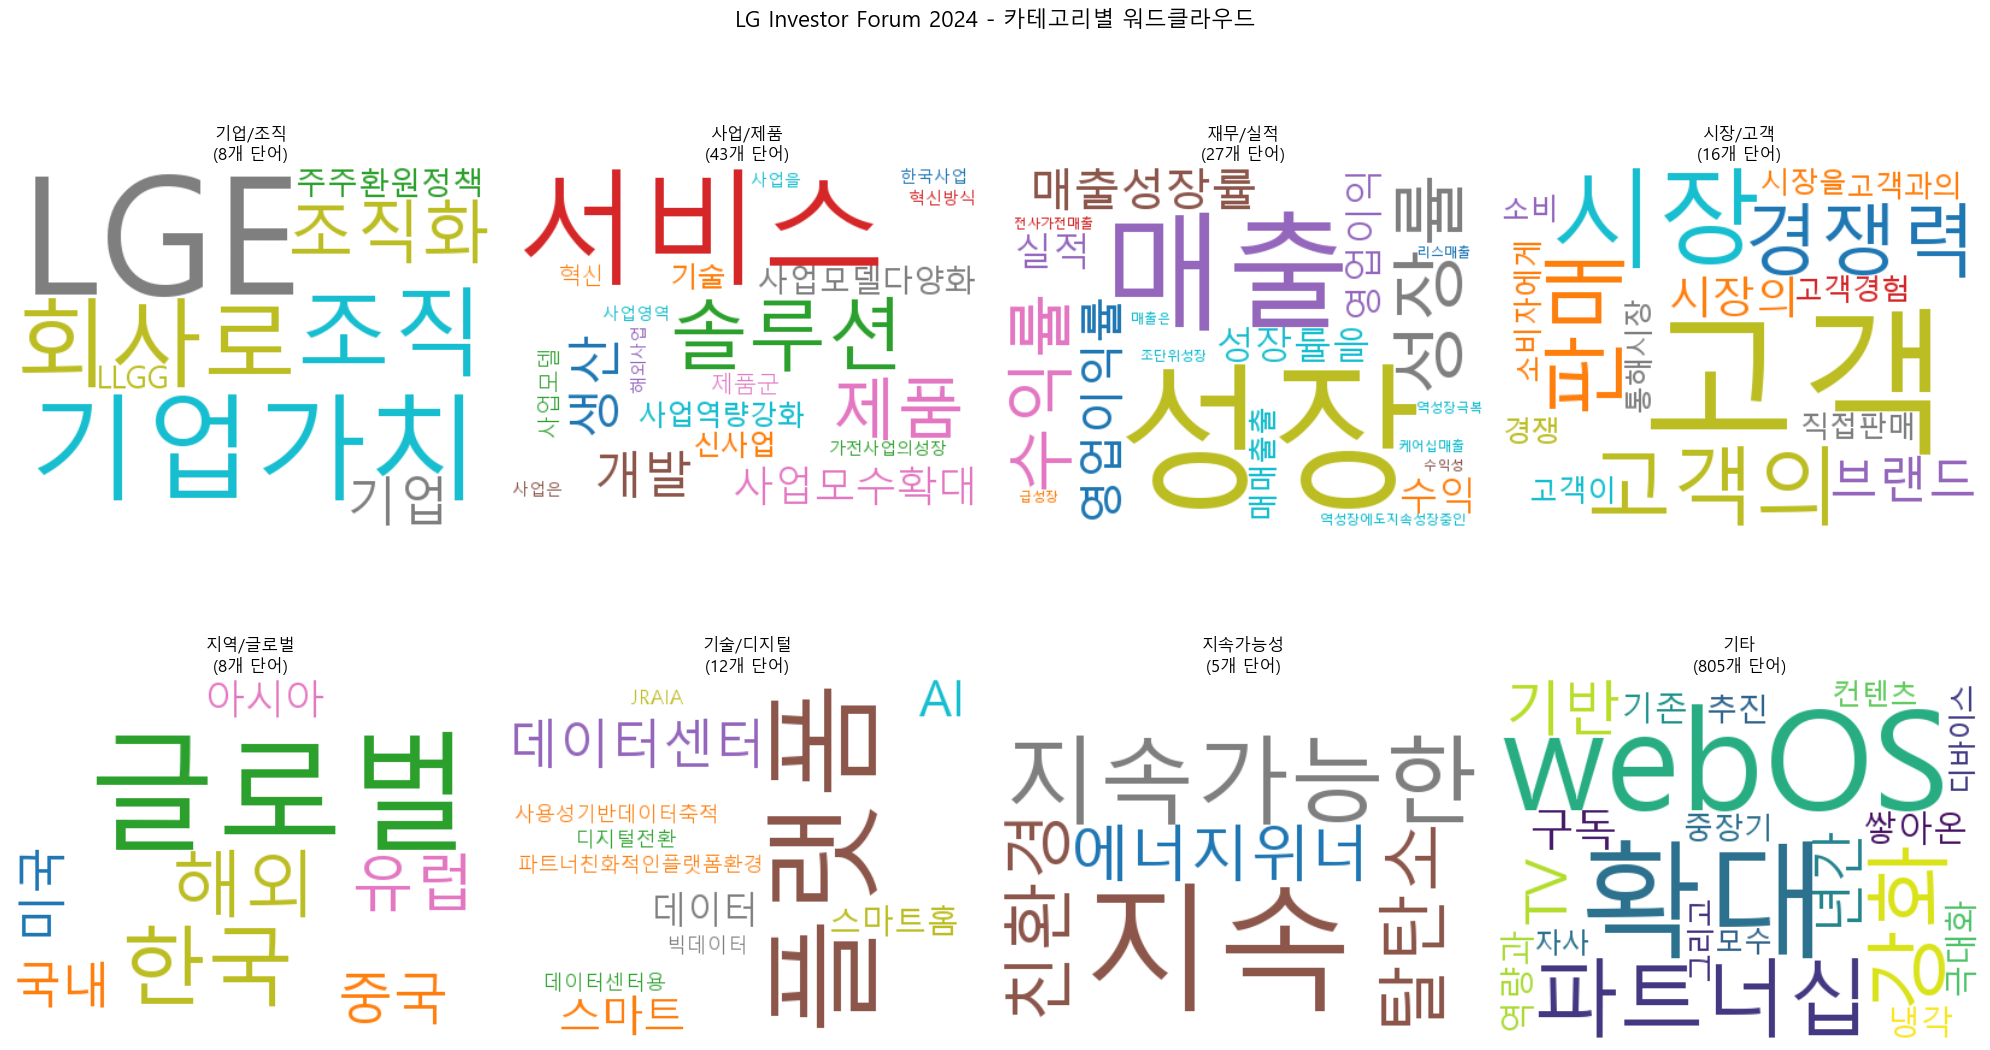


카테고리별 단어 통계:
기업/조직: 8개 단어, 총 빈도 19
  상위 3개: LGE(8), 기업가치(3), 조직(2)
사업/제품: 43개 단어, 총 빈도 157
  상위 3개: 서비스(62), 솔루션(17), 제품(12)
재무/실적: 27개 단어, 총 빈도 108
  상위 3개: 성장(42), 매출(26), 성장률(5)
시장/고객: 16개 단어, 총 빈도 72
  상위 3개: 고객(28), 시장(10), 고객의(6)
지역/글로벌: 8개 단어, 총 빈도 63
  상위 3개: 글로벌(29), 한국(10), 해외(7)
기술/디지털: 12개 단어, 총 빈도 88
  상위 3개: 플랫폼(45), 데이터센터(11), AI(10)
지속가능성: 5개 단어, 총 빈도 9
  상위 3개: 지속(4), 지속가능한(2), 탈탄소(1)

기타: 805개 단어, 총 빈도 1927


In [25]:
def categorize_words(word_freq):
    """
    단어를 카테고리별로 분류
    """
    if not word_freq:
        return {}
    
    categories = {
        '기업/조직': ['LG', 'LG전자', '회사', '기업', '조직', '임직원', '경영진', '이사회', '주주'],
        '사업/제품': ['사업', '제품', '서비스', '솔루션', '기술', '혁신', '개발', '생산', '제조'],
        '재무/실적': ['매출', '수익', '이익', '손실', '투자', '자본', '비용', '성장', '실적'],
        '시장/고객': ['시장', '고객', '소비자', '경쟁', '점유율', '브랜드', '마케팅', '판매'],
        '지역/글로벌': ['한국', '미국', '중국', '유럽', '아시아', '글로벌', '해외', '국내'],
        '기술/디지털': ['AI', '인공지능', '디지털', '스마트', '데이터', '플랫폼', '시스템'],
        '지속가능성': ['ESG', '환경', '탄소', '지속가능', '친환경', '에너지', '재활용']
    }
    
    categorized = {cat: {} for cat in categories.keys()}
    uncategorized = {}
    
    for word, freq in word_freq.items():
        assigned = False
        for category, keywords in categories.items():
            if any(keyword in word or word in keyword for keyword in keywords):
                categorized[category][word] = freq
                assigned = True
                break
        
        if not assigned:
            uncategorized[word] = freq
    
    # 각 카테고리별 상위 단어들로 워드클라우드 생성
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    axes = axes.flatten()
    
    for i, (category, words) in enumerate(categorized.items()):
        if words and i < len(axes):
            # 해당 카테고리의 상위 20개 단어만 사용
            top_words = dict(sorted(words.items(), key=lambda x: x[1], reverse=True)[:20])
            
            if top_words:
                wordcloud = WordCloud(
                    font_path='C:/Windows/Fonts/malgun.ttf',
                    width=400,
                    height=300,
                    background_color='white',
                    max_words=20,
                    colormap='tab10'
                ).generate_from_frequencies(top_words)
                
                axes[i].imshow(wordcloud, interpolation='bilinear')
                axes[i].set_title(f'{category}\n({len(words)}개 단어)', fontsize=12)
                axes[i].axis('off')
            else:
                axes[i].text(0.5, 0.5, f'{category}\n데이터 없음', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].axis('off')
    
    # 마지막 축은 기타 단어들
    if uncategorized:
        top_uncategorized = dict(sorted(uncategorized.items(), key=lambda x: x[1], reverse=True)[:20])
        wordcloud = WordCloud(
            font_path='C:/Windows/Fonts/malgun.ttf',
            width=400,
            height=300,
            background_color='white',
            max_words=20,
            colormap='viridis'
        ).generate_from_frequencies(top_uncategorized)
        
        axes[-1].imshow(wordcloud, interpolation='bilinear')
        axes[-1].set_title(f'기타\n({len(uncategorized)}개 단어)', fontsize=12)
        axes[-1].axis('off')
    
    plt.suptitle('LG Investor Forum 2024 - 카테고리별 워드클라우드', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 카테고리별 통계 출력
    print("\n카테고리별 단어 통계:")
    print("=" * 50)
    for category, words in categorized.items():
        total_freq = sum(words.values())
        print(f"{category}: {len(words)}개 단어, 총 빈도 {total_freq}")
        if words:
            top_3 = sorted(words.items(), key=lambda x: x[1], reverse=True)[:3]
            print(f"  상위 3개: {', '.join([f'{w}({f})' for w, f in top_3])}")
    
    print(f"\n기타: {len(uncategorized)}개 단어, 총 빈도 {sum(uncategorized.values())}")
    
    return categorized, uncategorized

# 카테고리별 분석 실행
if 'word_freq' in locals() and word_freq:
    categorized_words, other_words = categorize_words(word_freq)
else:
    print("분석할 데이터가 없습니다.")

## 8. 결과 저장

In [26]:
def save_results(word_freq, output_dir="./output"):
    """
    분석 결과를 파일로 저장
    """
    import os
    from datetime import datetime
    
    # 출력 디렉토리 생성
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 1. 단어 빈도 CSV 저장
    if word_freq:
        df = pd.DataFrame(list(word_freq.items()), columns=['단어', '빈도'])
        df = df.sort_values('빈도', ascending=False).reset_index(drop=True)
        csv_path = os.path.join(output_dir, f'word_frequency_{timestamp}.csv')
        df.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"단어 빈도 데이터 저장: {csv_path}")
    
    # 2. 워드클라우드 이미지 저장
    if 'wc_all' in locals() and wc_all:
        img_path = os.path.join(output_dir, f'wordcloud_all_{timestamp}.png')
        wc_all.to_file(img_path)
        print(f"전체 워드클라우드 저장: {img_path}")
    
    if 'wc_top' in locals() and wc_top:
        img_path = os.path.join(output_dir, f'wordcloud_top50_{timestamp}.png')
        wc_top.to_file(img_path)
        print(f"상위 50 워드클라우드 저장: {img_path}")
    
    # 3. 분석 보고서 텍스트 저장
    if word_freq:
        report_path = os.path.join(output_dir, f'analysis_report_{timestamp}.txt')
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write("LG Investor Forum 2024 워드클라우드 분석 보고서\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"분석 일시: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"총 추출 단어 수: {len(word_freq):,}개\n")
            f.write(f"총 단어 빈도: {sum(word_freq.values()):,}회\n\n")
            
            f.write("상위 50개 단어 빈도:\n")
            f.write("-" * 30 + "\n")
            for i, (word, freq) in enumerate(word_freq.most_common(50), 1):
                f.write(f"{i:2d}. {word}: {freq}회\n")
        
        print(f"분석 보고서 저장: {report_path}")
    
    print(f"\n모든 결과가 '{output_dir}' 폴더에 저장되었습니다.")

# 결과 저장 실행
if 'word_freq' in locals() and word_freq:
    save_results(word_freq)
else:
    print("저장할 데이터가 없습니다.")

단어 빈도 데이터 저장: ./output\word_frequency_20250730_153457.csv
분석 보고서 저장: ./output\analysis_report_20250730_153457.txt

모든 결과가 './output' 폴더에 저장되었습니다.


## 9. 분석 요약

In [27]:
def generate_summary(word_freq):
    """
    분석 결과 요약 생성
    """
    if not word_freq:
        print("요약할 데이터가 없습니다.")
        return
    
    print("\n" + "="*60)
    print("         LG INVESTOR FORUM 2024 워드클라우드 분석 요약")
    print("="*60)
    
    total_words = len(word_freq)
    total_frequency = sum(word_freq.values())
    
    print(f"📊 분석 통계:")
    print(f"   • 총 고유 단어 수: {total_words:,}개")
    print(f"   • 총 단어 출현 횟수: {total_frequency:,}회")
    print(f"   • 평균 단어 빈도: {total_frequency/total_words:.1f}회")
    
    print(f"\n🏆 최고 빈도 단어 TOP 10:")
    for i, (word, freq) in enumerate(word_freq.most_common(10), 1):
        percentage = (freq / total_frequency) * 100
        print(f"   {i:2d}. {word:<15} {freq:3d}회 ({percentage:.1f}%)")
    
    # 단어 길이 분석
    word_lengths = [len(word) for word in word_freq.keys()]
    avg_length = sum(word_lengths) / len(word_lengths)
    
    print(f"\n📏 단어 길이 분석:")
    print(f"   • 평균 단어 길이: {avg_length:.1f}자")
    print(f"   • 최장 단어: {max(word_freq.keys(), key=len)} ({len(max(word_freq.keys(), key=len))}자)")
    print(f"   • 최단 단어: {min(word_freq.keys(), key=len)} ({len(min(word_freq.keys(), key=len))}자)")
    
    # 한글 vs 영어 분석
    korean_words = [w for w in word_freq.keys() if re.search(r'[가-힣]', w)]
    english_words = [w for w in word_freq.keys() if re.search(r'[A-Za-z]', w) and not re.search(r'[가-힣]', w)]
    
    print(f"\n🌐 언어별 분석:")
    print(f"   • 한글 포함 단어: {len(korean_words)}개 ({len(korean_words)/total_words*100:.1f}%)")
    print(f"   • 영어 단어: {len(english_words)}개 ({len(english_words)/total_words*100:.1f}%)")
    
    print(f"\n💡 주요 키워드 인사이트:")
    top_10_words = [word for word, _ in word_freq.most_common(10)]
    
    business_words = [w for w in top_10_words if any(keyword in w.lower() for keyword in ['lg', '전자', '사업', '기업', '회사'])]
    if business_words:
        print(f"   • 기업/사업 관련: {', '.join(business_words)}")
    
    financial_words = [w for w in top_10_words if any(keyword in w.lower() for keyword in ['매출', '수익', '성장', '투자', '이익'])]
    if financial_words:
        print(f"   • 재무/성과 관련: {', '.join(financial_words)}")
    
    tech_words = [w for w in top_10_words if any(keyword in w.lower() for keyword in ['ai', '디지털', '기술', '혁신', '스마트'])]
    if tech_words:
        print(f"   • 기술/혁신 관련: {', '.join(tech_words)}")
    
    print("\n" + "="*60)
    print("분석이 완료되었습니다. 위의 워드클라우드와 차트를 참고하세요!")
    print("="*60)

# 요약 보고서 생성
if 'word_freq' in locals() and word_freq:
    generate_summary(word_freq)
else:
    print("요약할 데이터가 없습니다.")


         LG INVESTOR FORUM 2024 워드클라우드 분석 요약
📊 분석 통계:
   • 총 고유 단어 수: 924개
   • 총 단어 출현 횟수: 2,443회
   • 평균 단어 빈도: 2.6회

🏆 최고 빈도 단어 TOP 10:
    1. 서비스              62회 (2.5%)
    2. 플랫폼              45회 (1.8%)
    3. 성장               42회 (1.7%)
    4. webOS            39회 (1.6%)
    5. 확대               30회 (1.2%)
    6. 글로벌              29회 (1.2%)
    7. 고객               28회 (1.1%)
    8. 파트너십             27회 (1.1%)
    9. 강화               27회 (1.1%)
   10. 매출               26회 (1.1%)

📏 단어 길이 분석:
   • 평균 단어 길이: 3.9자
   • 최장 단어: SSoolluuttiioonn (16자)
   • 최단 단어: 추진 (2자)

🌐 언어별 분석:
   • 한글 포함 단어: 693개 (75.0%)
   • 영어 단어: 231개 (25.0%)

💡 주요 키워드 인사이트:
   • 재무/성과 관련: 성장, 매출

분석이 완료되었습니다. 위의 워드클라우드와 차트를 참고하세요!
